In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
from shared_logic import load_customer_data, save_dataframe

df_pca = load_customer_data('processed_pca_data.csv')

# Notebook 3: Comparative Clustering Results
This notebook moves from geometric representation to model comparison and validation. We evaluate candidate cluster counts using complementary metrics and finalize a reproducible K-Means configuration.

**Objectives:**
- Compare candidate values of $k$ using WCSS and Silhouette diagnostics.
- Select a defensible clustering configuration with explicit mathematical criteria.
- Produce labeled PCA data for downstream profiling in Notebook 4.

## 1. The Elbow Method & Optimization Strategy

To determine the optimal number of clusters ($k$), we must find a balance between model complexity and error reduction. We achieve this by analyzing the **Within-Cluster Sum of Squares (WCSS)** and utilizing advanced initialization techniques.

### 1.1. Mathematical Objective (WCSS)
WCSS measures the **compactness** of our clusters. It represents the sum of squared Euclidean distances between each data point and its assigned cluster centroid. Our goal is to minimize this objective function:

$$WCSS = \sum_{j=1}^{k} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2$$

**Where:**
* $k$ is the total number of clusters.
* $C_j$ is the set of observations belonging to cluster $j$.
* $\mu_j$ is the **centroid** (arithmetic mean) of cluster $j$.
* $\|x_i - \mu_j\|^2$ is the squared **$L_2$ norm** (Euclidean distance).

### 1.2. The "Elbow" Heuristic
We plot WCSS against different values of $k$ to identify the **"Elbow Point"**—the threshold where the rate of decrease in error significantly slows down.
* **Under-fitting (Low $k$):** High WCSS indicates clusters are too broad to capture specific behaviors.
* **Over-fitting (High $k$):** Diminishing returns where adding more clusters creates segments that are too small to be actionable for business strategy.

### 1.3. Algorithmic Refinement: k-means++
Standard K-Means is sensitive to the initial placement of centroids, often falling into **local optima** (the "Random Initialization Trap"). To ensure a globally stable solution, we implement the **`k-means++`** seeding algorithm.

Instead of uniform random selection, `k-means++` selects the first centroid randomly and each subsequent one with a probability $P(x)$ proportional to its distance from existing centroids:

$$P(x) = \frac{D(x)^2}{\sum_{x \in X} D(x)^2}$$

This mathematical approach improves centroid initialization in expectation and typically yields more stable, reproducible segments, though it does not guarantee the global minimum for every run.

The mathematically optimal number of clusters is: 3


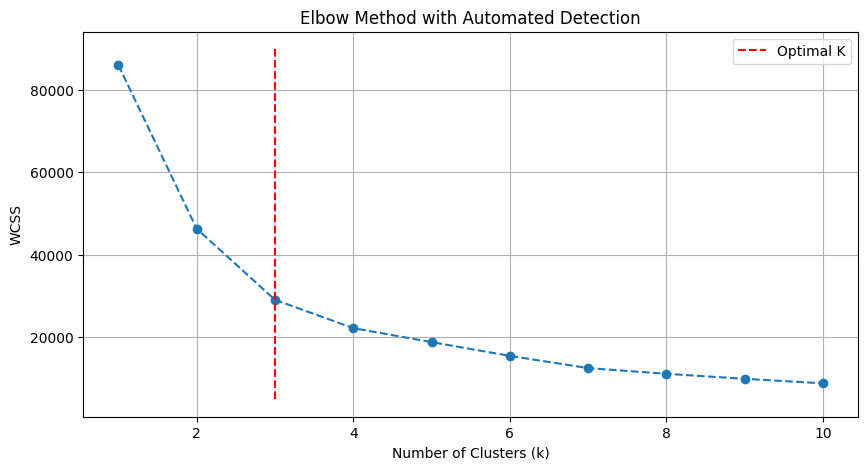

In [5]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_pca)
    wcss.append(kmeans.inertia_)

kn = KneeLocator(k_range, wcss, curve='convex', direction='decreasing')
optimal_k = kn.elbow

print(f"The mathematically optimal number of clusters is: {optimal_k}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.vlines(optimal_k, plt.ylim()[0], plt.ylim()[1], linestyles='--', colors='r', label='Optimal K')
plt.title('Elbow Method with Automated Detection')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.legend()
plt.grid(True)
plt.show()

###  Automated Elbow Method Analysis

In this section, we perform the core optimization for our clustering model. The goal is to find the "sweet spot" where the number of clusters is high enough to capture meaningful patterns but low enough to remain actionable for business strategy.

#### **Logic and Implementation:**

1.  **The WCSS Loop**:
    * We iterate through a range of clusters ($k=1$ to $k=10$).
    * **`init='k-means++'`**: We use this advanced initialization strategy to ensure that the initial centroids are placed far apart. This leads to better convergence and prevents the algorithm from getting stuck in local optima.
    * **`kmeans.inertia_`**: For each $k$, we calculate the **Inertia** (Within-Cluster Sum of Squares). This represents the total sum of squared distances from each customer point to their assigned cluster center.

2.  **Automated "Knee" Detection**:
    * Instead of relying on a subjective visual inspection of the graph, we implement the **`KneeLocator`** algorithm from the `kneed` library.
    * **`curve='convex'`** & **`direction='decreasing'`**: These parameters match the mathematical shape of our WCSS plot.
    * The tool identifies the point of maximum curvature, providing an objective and reproducible `optimal_k`.

3.  **Visualization**:
    * The generated plot illustrates the "Elbow." A sharp drop followed by a gradual decrease indicates that the algorithm has successfully identified the underlying structure of the customer data.

## 2. Validation via Silhouette Analysis

While the Elbow Method (WCSS) measures **compactness** (intra-cluster distance), the **Silhouette Score** focuses on **separation** — evaluating how distinct the clusters are from one another.

### 2.1. Mathematical Definition
The Silhouette Coefficient $s(i)$ for a single observation $i$ is a geometric measure of structural validity. It is derived using two key metrics:

1.  **Cohesion $a(i)$**: The average distance between point $i$ and all other points within its own cluster.
2.  **Separation $b(i)$**: The average distance between point $i$ and all points in the nearest neighboring cluster (the cluster $i$ is not part of).

The coefficient is calculated as:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

### 2.2. Interpretation of the Metric
The resulting score ranges from **-1 to +1**, providing a clear indicator of clustering quality:

* **$s(i) \approx +1$ (Excellent Separation):** The point is far from neighboring clusters, indicating a highly reliable assignment ($a(i) \ll b(i)$).
* **$s(i) \approx 0$ (Decision Boundary):** The point lies on or very close to the boundary between two clusters, suggesting overlapping segments.
* **$s(i) < 0$ (Misclassification):** The point is closer to a neighboring cluster than to its own, indicating a likely incorrect assignment.

### 2.3. Business & Engineering Goal
By optimizing for a higher Silhouette Score, we ensure that our segments are not just mathematical artifacts but **distinct behavioral personas**. This statistical validation allows us to build more precise marketing strategies, as customers in different groups will have truly unique financial signatures.

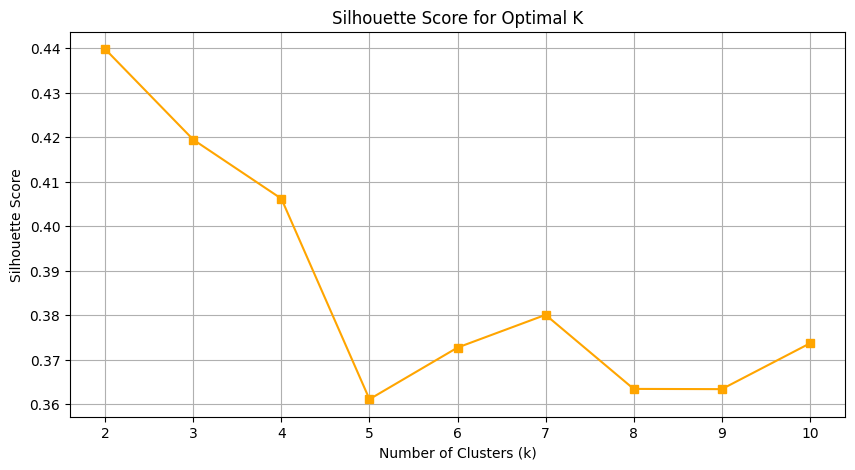

In [6]:
silhouette_avg = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    cluster_labels = kmeans.fit_predict(df_pca)
    silhouette_avg.append(silhouette_score(df_pca, cluster_labels))

plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), silhouette_avg, marker='s', color='orange')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

## 3. Final Model Implementation

Based on the combined analysis of the **Elbow Method** and **Silhouette Scores**, we select $k$ using an explicit rule:
- Start from the Elbow candidate when it is detected.
- Switch to the silhouette-optimal candidate only when the silhouette improvement is materially larger (threshold: $\Delta s > 0.02$).

This preserves reproducibility, keeps model-selection logic aligned with observed data, and prevents overreacting to negligible metric differences.

The selected segmentation should balance:
- **Granularity:** Sufficiently detailed groups for targeted strategy.
- **Simplicity:** A manageable number of interpretable customer personas.

### Implementation Details
- **Algorithm:** K-Means clustering.
- **Initialization:** `k-means++` for stable centroid seeding and improved convergence behavior.
- **Reproducibility:** fixed `random_state` so assignments are consistent across runs.

Elbow k = 3; Silhouette-best k = 2


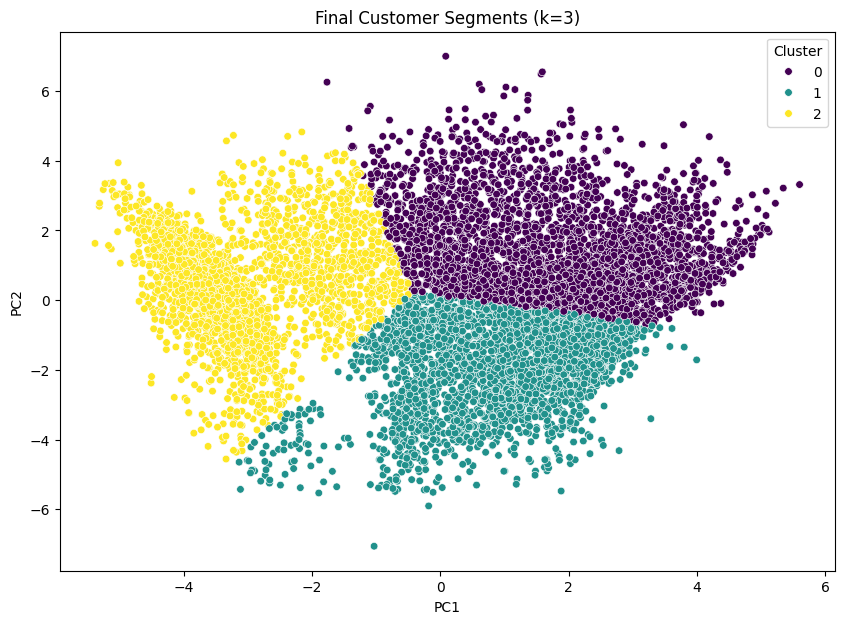

In [7]:
silhouette_k = int(np.argmax(silhouette_avg) + 2)
if optimal_k is None:
    optimal_k = silhouette_k
    print(f"Elbow point not detected; using silhouette-optimal k = {optimal_k}")
else:
    print(f"Elbow k = {optimal_k}; Silhouette-best k = {silhouette_k}")

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df_pca['Cluster'] = kmeans_final.fit_predict(df_pca)

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=30)
plt.title(f'Final Customer Segments (k={optimal_k})')
plt.show()

## 4. Synthesis: From Latent Space to Financial Reality

### 4.1. Visualization & Initial Findings
The final scatter plot illustrates our 8,950 customers partitioned into **$k^*$** segments within the PCA-reduced latent space, where $k^*$ is selected by the decision rule defined above. While real-world financial data is inherently noisier than synthetic models, the boundaries between clusters remain statistically visible.

The use of Principal Components (PC1 and PC2) has allowed us to collapse high-dimensional variance into a 2D plane, making the global structure of our customer base interpretable.

### 4.2. Mathematical Transition: Space Mapping & Centroid Profiling
Having optimized the model in the reduced space, our final challenge is to perform an **Inverse Mapping**. To transform these abstract clusters into business intelligence, we evaluate the **Central Tendency ($\mu$)** of each segment back in the original high-dimensional feature space.

We define each segment $j$ by its mean vector across all financial features $f$:

$$\bar{V}_{j, f} = \frac{1}{|C_j|} \sum_{x \in C_j} x_f$$

### **Next Steps:**
In **Notebook 4 (Cluster Profiling)**, we will "decode" these vectors by joining cluster labels back to the original financial table via consistent row alignment from the preprocessing pipeline. By mapping labels to original metrics—such as **Balance, Purchases, and Cash Advance**—we can define actionable **Business Personas** and verify whether the geometric structure remains economically meaningful.

In [8]:
save_dataframe(df_pca, 'data_with_clusters.csv', index=False)
print('Clusters saved successfully!')

Clusters saved successfully!


## 5. Wrap-Up
Notebook 3 established a data-driven cluster count using complementary compactness and separation criteria, then trained a reproducible final K-Means model in PCA space.

The exported labeled dataset now carries the mapping
$$x_i \mapsto (\mathrm{PC1}_i, \mathrm{PC2}_i, c_i),$$
which is the required input for segment interpretation.

In Notebook 4, we move from geometric clusters to feature-level profiling by estimating per-cluster central tendencies in the original financial variables and translating them into business personas.